# OCRP HR Conv Mechanics

This notebook is a focused analysis of the HR masked equivariant convolution used after OCRP in the standard `4x4` experiment.

Goals:
- explain exactly what the HR conv computes
- separate the TP branch from the residual path
- show why the branch is **not automatically a smoothing layer**
- inspect how the role of the HR conv evolves across training, especially around the bend near epoch 30


## Core Equations

For a feature image `x` on the HR lattice, `CosineMaskedEquivariantSpatialConv` does:

1. Extract a local patch around each HR pixel.
2. Compute cosine similarity between the center feature and each patch member.
3. Build masked spatial weights:
   - `base_w = softmax(spatial_logits)`
   - `mask = sigmoid(temp * (cos - thr))` for soft masking, or an indicator for hard masking
   - the center pixel is always forced into the mask
4. Renormalize the surviving weights and form the pooled neighborhood context
   - `neigh = sum_j w_j patch_j / sum_j w_j`
5. Apply a same-out equivariant tensor product with the center feature
   - `tp = TP(center, neigh)`
6. Add the residual path if enabled
   - `out = tp + beta * center`

So this layer is **not** a plain averaging filter. It is a learnable equivariant transform of `(center, neigh)` plus an optional weighted skip path.

That difference matters:
- a true smoother would be biased toward something like `center + alpha * (neigh - center)`
- this layer is biased toward `beta * center + TP(center, neigh)`

If the model can solve the task with a mostly-residual solution, it may never discover strong smoothing behavior unless the loss or parameterization makes that attractive.


In [62]:
from __future__ import annotations

import importlib
import inspect
import json
import sys
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Find repo root robustly whether the notebook is launched from repo root or ideas/
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'models' / 'SR_ocrp.py').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from training.config_utils import load_and_prepare_config
from training.data_loading import build_dataloader
from training.train_iso_embedding_sr_attn import _flatten_quat_chw_batch, _unpack_batch

print('Repo root:', REPO_ROOT)


Repo root: /data/home/umang/Materials/Reynolds-QSR_4x1


## Experiment Under Study

Default target:
- `experiments/IN718/iso_embedding_ocrp_01_4x4`

This notebook is written to analyze the standard `4x4` OCRP experiment with the HR conv stack enabled. It should still work on future checkpoints as long as the model class remains compatible.


In [63]:
EXP_DIR = REPO_ROOT / 'experiments' / 'IN718' / 'iso_embedding_4x4_ocrp_01'
CONFIG_PATH = EXP_DIR / 'config_new.json'
CHECKPOINT_DIR = EXP_DIR / 'checkpoints'
VAL_TAKE_FIRST = 4

cfg = load_and_prepare_config(CONFIG_PATH)
with open(CONFIG_PATH, 'r') as f:
    cfg_json = json.load(f)
SAVE_EVERY = int(getattr(cfg, 'save_every', 1))
available_epoch_labels = sorted(
    p.stem.split('_')[-1]
    for p in CHECKPOINT_DIR.glob('epoch_*.pt')
)
# Saving frequency is no longer the older dense 5-epoch sweep this notebook
# originally assumed. Build the sweep from the checkpoint files that
# actually exist, preferring the epochs around the bend near epoch 30.
CHECKPOINT_LABELS = [label for label in available_epoch_labels if 20 <= int(label) <= 40]
if not CHECKPOINT_LABELS:
    CHECKPOINT_LABELS = list(available_epoch_labels)
CHECKPOINT_LABELS = CHECKPOINT_LABELS + ['best']

print('save_every from config:', SAVE_EVERY)
print('available epoch checkpoints:', available_epoch_labels)
print('checkpoint sweep labels:', CHECKPOINT_LABELS)
print('Experiment:', EXP_DIR)
print('use_hr_conv1:', cfg_json.get('use_hr_conv1'))
print('hr_conv1_kernel_size:', cfg_json.get('hr_conv1_kernel_size'))
print('hr_conv1_residual_weight:', cfg_json.get('hr_conv1_residual_weight'))
print('use_hr_conv2:', cfg_json.get('use_hr_conv2'))
print('hr_conv2_kernel_size:', cfg_json.get('hr_conv2_kernel_size'))
print('hr_conv2_residual_weight:', cfg_json.get('hr_conv2_residual_weight'))
print('hr_conv_feature_mask_soft:', cfg_json.get('hr_conv_feature_mask_soft'))
print('hr_conv_feature_mask_cosine_threshold:', cfg_json.get('hr_conv_feature_mask_cosine_threshold', cfg_json.get('conv_feature_mask_cosine_threshold')))


Using symmetry group from config: Oh
Overridden config values:
  - dataset_root: /data/home/umang/Materials/Materials_data_mount/datasets/IN718 (default: )
  - epochs: 150 (default: 10)
  - batch_size: 8 (default: 4)
  - symmetry_group: Oh (default: O)
  - use_amp: True (default: False)
  - decoder_steps: 60 (default: 1)
  - decoder_lr: 0.03 (default: 0.05)
  - save_every: 10 (default: 5)
  - viz_every: 10 (default: 5)
  - num_workers: 8 (default: 0)
  - persistent_workers: True (default: False)
  - prefetch_factor: 4 (default: 2)
  - preload: True (default: False)
  - preload_torch: True (default: False)
  - cudnn_benchmark: True (default: False)
  - min_free_cuda_gb: 4.0 (default: 0.0)
  - model.type: iso_embedding_ocrp (default: iso_embedding_sr_attn)
  - logging.val_freq: 10 (default: 1)
Using existing symmetry files for Oh
save_every from config: 10
available epoch checkpoints: ['0010', '0020', '0030', '0040', '0050', '0060', '0070', '0080', '0090', '0100', '0110', '0120', '0130',

## Helper: Build the Exact Model Class from the Experiment Config

We instantiate the model the same way the trainer does, then load any checkpoint we want to inspect.


In [64]:
def build_model_from_cfg(cfg, device: str = 'cpu'):
    model_cfg = getattr(cfg, 'model', {}) or {}
    if isinstance(model_cfg, dict):
        model_module = model_cfg.get('model_module', 'models.SR_ocrp')
        model_class = model_cfg.get('model_class', 'IsoEmbeddingSROCRP')
    else:
        model_module = getattr(model_cfg, 'model_module', 'models.SR_ocrp')
        model_class = getattr(model_cfg, 'model_class', 'IsoEmbeddingSROCRP')
    Cls = getattr(importlib.import_module(model_module), model_class)
    sig = inspect.signature(Cls.__init__).parameters
    kwargs = {}
    for name in sig:
        if name == 'self':
            continue
        if name == 'device':
            kwargs[name] = device
        elif name == 'upsample_factor':
            kwargs[name] = getattr(cfg, 'upsample_factor', getattr(cfg, 'scale', 4))
        elif hasattr(cfg, name):
            kwargs[name] = getattr(cfg, name)
    model = Cls(**kwargs).to(device).eval()
    return model


def load_checkpoint_into_model(model, ckpt_path: Path):
    ckpt = torch.load(ckpt_path, map_location='cpu')
    model.load_state_dict(ckpt['model_state_dict'])
    return ckpt


model = build_model_from_cfg(cfg, device='cpu')
print(type(model).__name__)


ValueError: OCRP currently expects kmax_slots=4, got 6

## Helper: Build a Small Validation Slice

We keep this intentionally small because the point is understanding the mechanics, not benchmarking the whole split.


In [ ]:
val_loader = build_dataloader(
    dataset_root=cfg.dataset_root,
    split='Val',
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    preload=False,
    preload_torch=False,
    persistent_workers=False,
    prefetch_factor=2,
    take_first=VAL_TAKE_FIRST,
    return_lr_boundary_map=False,
)
val_batches = list(val_loader)
print('Val mini-slice size:', len(val_batches))


Val mini-slice size: 4


## Helper: Exact Branch Decomposition

This reconstructs the internals of `CosineMaskedEquivariantSpatialConv` directly from the layer state:
- pooled neighborhood context `neigh`
- TP branch `tp = TP(center, neigh)`
- residual branch `beta * center`

That lets us answer questions like:
- Is the final output mostly residual?
- Is the TP branch large or small?
- Is the pooled neighborhood actually different from the center?
- Is the TP branch additive or subtractive relative to the residual path?


In [ ]:
def decompose_conv(conv, inp: torch.Tensor, img_shape: tuple[int, int]):
    bsz, n, cdim = inp.shape
    h, w = img_shape
    feat_img = inp.view(bsz, h, w, cdim).permute(0, 3, 1, 2).contiguous()
    patches = conv._extract_patches(feat_img)
    center = feat_img.unsqueeze(-1).unsqueeze(-1)

    dot = (patches * center).sum(dim=1)
    patch_norm = patches.pow(2).sum(dim=1).clamp_min(conv.eps).sqrt()
    center_norm = feat_img.pow(2).sum(dim=1).clamp_min(conv.eps).sqrt().unsqueeze(-1).unsqueeze(-1)
    cosine = (dot / (patch_norm * center_norm).clamp_min(conv.eps)).clamp(-1.0, 1.0)

    masked_w = conv._masked_spatial_weights(cosine)
    denom = masked_w.sum(dim=(-1, -2)).clamp_min(conv.eps)
    norm_w = masked_w / denom.unsqueeze(-1).unsqueeze(-1)
    neigh = (patches * masked_w.unsqueeze(1)).sum(dim=(-1, -2)) / denom.unsqueeze(1)

    feat_flat = inp.reshape(bsz * n, cdim)
    neigh_flat = neigh.permute(0, 2, 3, 1).reshape(bsz * n, cdim)
    tp = conv.tp(feat_flat, neigh_flat).reshape(bsz, n, conv.out_dim)

    if conv.residual_proj is None:
        resid = conv.residual_weight * inp
    else:
        resid = conv.residual_weight * conv.residual_proj(feat_flat).reshape(bsz, n, conv.out_dim)

    return {
        'tp': tp,
        'resid': resid,
        'neigh': neigh.permute(0, 2, 3, 1).reshape(bsz, n, cdim),
        'norm_w': norm_w,
    }


def mean_norm(x: torch.Tensor) -> float:
    return float(x.norm(dim=-1).mean().item())


def mean_cos(a: torch.Tensor, b: torch.Tensor) -> float:
    aa = a.reshape(-1, a.shape[-1])
    bb = b.reshape(-1, b.shape[-1])
    return float(F.cosine_similarity(aa, bb, dim=-1, eps=1e-8).mean().item())


## Helper: Analyze One Checkpoint

This computes:
- raw OCRP feature error to the HR target feature
- error after HR conv 1
- error after the full HR stack
- TP/residual branch norm ratios for HR conv 1 and HR conv 2
- how much the pooled neighborhood is still aligned with the input
- how much of the normalized spatial weight sits on the center pixel

Interpretation hints:
- `tp/resid << 1`: residual dominates the final direction
- `cos(neigh, input) ~ 1`: context pooling is mostly producing an almost-colinear vector
- `center_weight` small but `cos(neigh, input) ~ 1`: the layer is mixing neighbors, but they are so similar that the pooled direction barely changes


In [ ]:
def analyze_checkpoint(model, ckpt_path: Path, val_batches):
    _ = load_checkpoint_into_model(model, ckpt_path)
    model.eval()

    conv1 = model.conv_hr1
    conv2 = getattr(model, 'conv_hr2', None)

    agg = {
        'tokens': 0,
        'raw_mse': 0.0,
        'conv1_mse': 0.0,
        'full_mse': 0.0,
        'tp1_norm': 0.0,
        'resid1_norm': 0.0,
        'tp2_norm': 0.0,
        'resid2_norm': 0.0,
        'cos_tp1_resid1': 0.0,
        'cos_neigh1_raw': 0.0,
        'center_w1': 0.0,
        'cos_tp2_resid2': 0.0,
        'cos_neigh2_in': 0.0,
        'center_w2': 0.0,
    }

    with torch.no_grad():
        for batch in val_batches:
            lr, hr, _ = _unpack_batch(batch)
            lr_flat, lr_shape = _flatten_quat_chw_batch(lr)
            hr_flat, hr_shape = _flatten_quat_chw_batch(hr)

            feat_lr = model.encode(lr_flat)
            feat_hr_pred, hr_pred_shape, aux = model._forward_sr_features(
                lr_quats=lr_flat,
                feat_lr=feat_lr,
                lr_shape=lr_shape,
                return_aux=True,
            )
            feat_hr_tgt = model.encode(hr_flat)

            raw = aux['feat_hr_raw_ocrp']
            post1 = aux['feat_hr_post_hr_conv1']
            full = aux['feat_hr_post_hr_conv']
            bsz, n, cdim = raw.shape
            t = bsz * n
            agg['tokens'] += t

            agg['raw_mse'] += float(F.mse_loss(raw, feat_hr_tgt).item()) * t
            agg['conv1_mse'] += float(F.mse_loss(post1, feat_hr_tgt).item()) * t
            agg['full_mse'] += float(F.mse_loss(full, feat_hr_tgt).item()) * t

            dec1 = decompose_conv(conv1, raw, hr_pred_shape)
            center_i1 = conv1.kernel_size // 2
            agg['tp1_norm'] += mean_norm(dec1['tp']) * t
            agg['resid1_norm'] += mean_norm(dec1['resid']) * t
            agg['cos_tp1_resid1'] += mean_cos(dec1['tp'], dec1['resid']) * t
            agg['cos_neigh1_raw'] += mean_cos(dec1['neigh'], raw) * t
            agg['center_w1'] += float(dec1['norm_w'][..., center_i1, center_i1].mean().item()) * t

            if conv2 is not None and getattr(model, 'use_hr_conv2', False):
                dec2 = decompose_conv(conv2, post1, hr_pred_shape)
                center_i2 = conv2.kernel_size // 2
                agg['tp2_norm'] += mean_norm(dec2['tp']) * t
                agg['resid2_norm'] += mean_norm(dec2['resid']) * t
                agg['cos_tp2_resid2'] += mean_cos(dec2['tp'], dec2['resid']) * t
                agg['cos_neigh2_in'] += mean_cos(dec2['neigh'], post1) * t
                agg['center_w2'] += float(dec2['norm_w'][..., center_i2, center_i2].mean().item()) * t

    for k in list(agg.keys()):
        if k != 'tokens':
            agg[k] /= max(agg['tokens'], 1)

    agg['tp1_over_resid1'] = agg['tp1_norm'] / max(agg['resid1_norm'], 1e-12)
    if agg['resid2_norm'] > 0:
        agg['tp2_over_resid2'] = agg['tp2_norm'] / agg['resid2_norm']
    else:
        agg['tp2_over_resid2'] = None
    return agg


## Best Checkpoint: What Is the HR Conv Actually Doing?

This first pass answers the immediate question:
- Is the TP branch doing meaningful work?
- Or does the network mostly flow through the residual path?


In [ ]:
best_stats = analyze_checkpoint(model, CHECKPOINT_DIR / 'best_model.pt', val_batches)
pprint(best_stats)


/tmp/ipykernel_1868126/2212568048.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


{'center_w1': 0.05567366909235716,
 'center_w2': 0.07519878633320332,
 'conv1_mse': 0.0025135261239483953,
 'cos_neigh1_raw': 0.9999856650829315,
 'cos_neigh2_in': 0.9999872148036957,
 'cos_tp1_resid1': 0.9999960213899612,
 'cos_tp2_resid2': 0.9999967962503433,
 'full_mse': 0.0008192940877052024,
 'raw_mse': 0.0861416719853878,
 'resid1_norm': 0.4384920820593834,
 'resid2_norm': 0.15726609528064728,
 'tokens': 65536,
 'tp1_norm': 0.08572849072515965,
 'tp1_over_resid1': 0.19550749998160685,
 'tp2_norm': 0.2171342521905899,
 'tp2_over_resid2': 1.3806806343293871}


### Reading the Best-Checkpoint Numbers

Typical patterns to look for:
- If `tp1_over_resid1` is much smaller than `1`, HR conv 1 is mostly residual-dominated.
- If `cos_tp1_resid1` is close to `-1`, the TP branch is mostly a subtractive correction against the residual path.
- If `center_w1` is small but `cos_neigh1_raw` is still near `1`, the layer is pooling many neighbors, but the pooled context still points almost the same way as the center.

That combination means:
- the layer **is not being ignored**
- but it is also **not acting like a strong smoother**
- it is behaving more like a small geometry-aware correction on top of a dominant skip path


In [ ]:
conv1 = model.conv_hr1
print('conv_hr1 tp.weight norm:', float(conv1.tp.weight.detach().norm().item()))
print('conv_hr1 spatial logits std:', float(conv1.spatial_logits.detach().std().item()))
print('conv_hr1 residual weight:', conv1.residual_weight)
print('conv_hr1 feature mask threshold:', conv1.feature_mask_cosine_threshold)
print('conv_hr1 feature mask soft:', conv1.feature_mask_soft)

if getattr(model, 'use_hr_conv2', False):
    conv2 = model.conv_hr2
    print('conv_hr2 tp.weight norm:', float(conv2.tp.weight.detach().norm().item()))
    print('conv_hr2 spatial logits std:', float(conv2.spatial_logits.detach().std().item()))
    print('conv_hr2 residual weight:', conv2.residual_weight)
    print('conv_hr2 feature mask threshold:', conv2.feature_mask_cosine_threshold)
    print('conv_hr2 feature mask soft:', conv2.feature_mask_soft)


conv_hr1 tp.weight norm: 2.0690534114837646
conv_hr1 spatial logits std: 0.47063401341438293
conv_hr1 residual weight: 0.3
conv_hr1 feature mask threshold: 0.97
conv_hr1 feature mask soft: False
conv_hr2 tp.weight norm: 3.778907060623169
conv_hr2 spatial logits std: 0.6864280700683594
conv_hr2 residual weight: 0.3
conv_hr2 feature mask threshold: 0.97
conv_hr2 feature mask soft: False


## Checkpoint Sweep Around Epoch 30

The training curve has a noticeable bend around epoch 30. This sweep checks whether that bend comes from:
- OCRP raw output getting better
- HR conv 1 becoming useful
- HR conv 2 becoming useful
- or a co-adaptation where OCRP becomes less final and the HR stack takes over more of the post-processing


In [ ]:
def resolve_ckpt(label: str) -> Path:
    if label == 'best':
        return CHECKPOINT_DIR / 'best_model.pt'
    return CHECKPOINT_DIR / f'epoch_{int(label):04d}.pt'

sweep = []
for label in CHECKPOINT_LABELS:
    stats = analyze_checkpoint(model, resolve_ckpt(label), val_batches)
    stats['epoch'] = label
    sweep.append(stats)

for row in sweep:
    pprint({k: row[k] for k in ['epoch','raw_mse','conv1_mse','full_mse','tp1_over_resid1','tp2_over_resid2']})


/tmp/ipykernel_1868126/2212568048.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


{'conv1_mse': 0.00791117874905467,
 'epoch': '0020',
 'full_mse': 0.009757351828739047,
 'raw_mse': 0.0014694082201458514,
 'tp1_over_resid1': 0.35023977573424114,
 'tp2_over_resid2': 0.0749635392561009}
{'conv1_mse': 0.007311263936571777,
 'epoch': '0030',
 'full_mse': 0.009485900402069092,
 'raw_mse': 0.0012461634032661095,
 'tp1_over_resid1': 0.2606277998119989,
 'tp2_over_resid2': 0.12199240638702154}
{'conv1_mse': 0.003390787518583238,
 'epoch': '0040',
 'full_mse': 0.007037904695607722,
 'raw_mse': 0.013109288411214948,
 'tp1_over_resid1': 0.2171812560051265,
 'tp2_over_resid2': 0.4046981099581482}
{'conv1_mse': 0.0025135261239483953,
 'epoch': 'best',
 'full_mse': 0.0008192940877052024,
 'raw_mse': 0.0861416719853878,
 'tp1_over_resid1': 0.19550749998160685,
 'tp2_over_resid2': 1.3806806343293871}


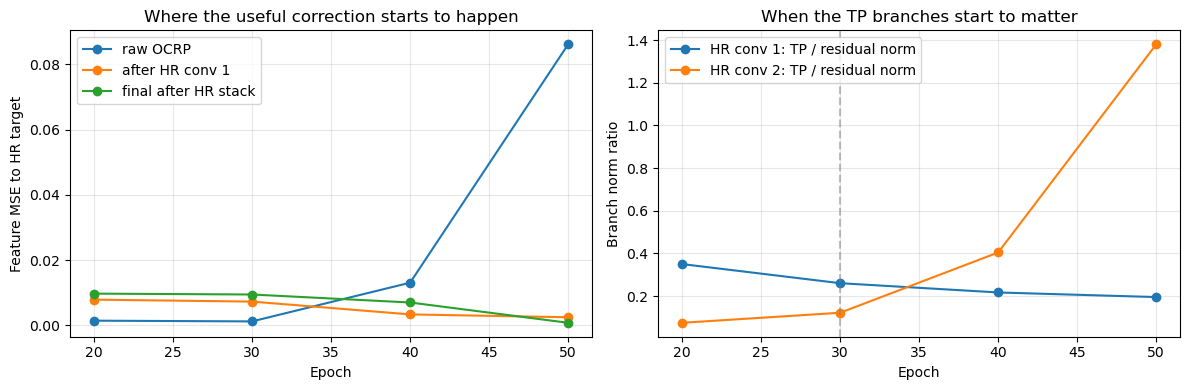

In [ ]:
best_anchor_epoch = int(CHECKPOINT_LABELS[-2]) if len(CHECKPOINT_LABELS) >= 2 else SAVE_EVERY
epoch_x = [
    int(r['epoch']) if r['epoch'] != 'best' else best_anchor_epoch + SAVE_EVERY
    for r in sweep
]
raw_y = [r['raw_mse'] for r in sweep]
conv1_y = [r['conv1_mse'] for r in sweep]
full_y = [r['full_mse'] for r in sweep]
tp1_ratio = [r['tp1_over_resid1'] for r in sweep]
tp2_ratio = [0.0 if r['tp2_over_resid2'] is None else r['tp2_over_resid2'] for r in sweep]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epoch_x, raw_y, marker='o', label='raw OCRP')
axes[0].plot(epoch_x, conv1_y, marker='o', label='after HR conv 1')
axes[0].plot(epoch_x, full_y, marker='o', label='final after HR stack')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Feature MSE to HR target')
axes[0].set_title('Where the useful correction starts to happen')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epoch_x, tp1_ratio, marker='o', label='HR conv 1: TP / residual norm')
axes[1].plot(epoch_x, tp2_ratio, marker='o', label='HR conv 2: TP / residual norm')
axes[1].axvline(30, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Branch norm ratio')
axes[1].set_title('When the TP branches start to matter')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## How to Read the Epoch-30 Bend

If the sweep shows the pattern we observed in terminal analysis, the story is:

1. **Early stage**
   - OCRP raw output is already the best approximation.
   - HR conv stages are weak or even harmful.
   - The network is mostly learning a stable OCRP representation with residual-dominated refinement.

2. **Around epoch 30**
   - The HR stack starts to become useful.
   - TP/residual ratios begin to rise.
   - The model starts to learn a division of labor instead of asking OCRP to be the final answer by itself.

3. **Later stage**
   - Raw OCRP may actually become *less* target-like by itself.
   - But the post-HR-conv output becomes better.
   - That means the network has become a **co-adapted two-stage system**:
     - OCRP produces features that are easier for the HR stack to refine
     - the HR stack does more of the final shaping

This is important: a bend in the total loss does **not** automatically mean the HR branch suddenly learned “smoothing.” It can mean the whole network changed regime and started relying on the HR stack for final correction.


## Why the HR Conv Is Not Automatically a Smoother

Even though it has neighborhood pooling, the HR conv is not initialized as a local average layer.

It starts from:
- `out = TP(center, neigh) + beta * center`

not from:
- `out = center + alpha * (neigh - center)`

That means:
- the TP branch is a general equivariant bilinear transform, not an explicit smoothing blend
- the residual path makes optimization easy by preserving a valid feature signal
- the easiest learned solution can be a small subtractive or rescaling correction rather than seam-smoothing

So if you want a branch that smooths from the start, the architecture needs a stronger smoothing prior than “TP + residual” by itself.


## Residual Path: What It Actually Does

The residual path is not just a shortcut for convenience. In practice it does three things:

1. **Stabilizes optimization**
   - The model does not need to discover identity-preserving TP behavior just to avoid damaging the feature.

2. **Anchors the feature manifold**
   - OCRP features already live in a decodable representation space.
   - The skip path keeps the HR conv from wandering too far off-manifold early.

3. **Changes what the TP branch learns**
   - With residual on, TP can learn a small correction.
   - With residual off, TP has to preserve the whole representation and refine it at the same time.
   - That is much harder.

This is why small positive residual weights can still train well, while `0.0` can collapse or become noisy.


## Link Back to the A1 TP Notebook Intuition

In the `A1_TensorProduct_Exploration` notebook, the self-TP case taught an important lesson:
- even when TP can represent a useful operation, the easiest learned behavior can be to scale or reweight an existing signal rather than invent a new transformation.

That same intuition shows up here:
- if `neigh` is already almost aligned with `center`, then `TP(center, neigh)` often behaves more like a learned rescaling/correction than a strong smoothing operator
- the residual path then becomes the dominant carrier of the final feature direction


## What the HR Conv Actually Learnt

The earlier cells told us **whether** the HR stack helps. The cells below ask a stricter question:
- what spatial prior each HR conv learned,
- which irrep-to-irrep tensor-product paths actually carry the learned correction,
- how often neighbors survive the cosine gate on real validation patches,
- and whether the TP branch points in the same direction as the missing HR correction.

This is an explicit weight-level and behavior-level probe of the trained checkpoint, not just another output visualization.


In [ ]:
import math
import numpy as np


def mean_norm(x: torch.Tensor) -> float:
    return float(x.norm(dim=-1).mean().item())


def safe_mean_cos(a: torch.Tensor, b: torch.Tensor) -> float:
    aa = a.reshape(-1, a.shape[-1])
    bb = b.reshape(-1, b.shape[-1])
    sim = F.cosine_similarity(aa, bb, dim=-1, eps=1e-8)
    return float(torch.nan_to_num(sim, nan=0.0).mean().item())


def irrep_block_rows(irreps):
    rows = []
    start = 0
    for idx, mul_ir in enumerate(irreps):
        dim = int(mul_ir.dim)
        rows.append(
            {
                'index': idx,
                'label': str(mul_ir),
                'slice': slice(start, start + dim),
                'dim': dim,
            }
        )
        start += dim
    return rows


def base_spatial_weight_map(conv):
    return F.softmax(conv.spatial_logits.detach().reshape(-1), dim=0).view(conv.kernel_size, conv.kernel_size)


def spatial_kernel_summary(conv):
    base = base_spatial_weight_map(conv).cpu()
    k = conv.kernel_size
    yy, xx = torch.meshgrid(torch.arange(k), torch.arange(k), indexing='ij')
    c = k // 2
    cheb = torch.maximum((yy - c).abs(), (xx - c).abs())
    center = cheb == 0
    ring1 = cheb == 1
    ring2plus = cheb >= 2
    entropy = float((-(base.clamp_min(1e-12) * base.clamp_min(1e-12).log()).sum() / math.log(base.numel())).item())
    row_mass = float(base[c, :].sum().item())
    col_mass = float(base[:, c].sum().item())
    return {
        'center_mass': float(base[center].sum().item()),
        'ring1_mass': float(base[ring1].sum().item()),
        'ring2plus_mass': float(base[ring2plus].sum().item()),
        'entropy_0to1': entropy,
        'row_mass': row_mass,
        'col_mass': col_mass,
        'row_col_gap': abs(row_mass - col_mass),
        'base_map': base,
        'center_mask': center,
        'ring1_mask': ring1,
        'ring2plus_mask': ring2plus,
    }


def tp_path_rows(conv):
    weights = conv.tp.weight.detach().cpu().view(-1)
    rows = []
    for idx, inst in enumerate(conv.tp.instructions):
        rows.append(
            {
                'path_idx': idx,
                'path': f"{conv.irreps_in[inst.i_in1]} x {conv.irreps_in[inst.i_in2]} -> {conv.irreps_out[inst.i_out]}",
                'weight': float(weights[idx].item()),
                'path_weight': float(inst.path_weight),
                'effective_scale': float(weights[idx].item() * inst.path_weight),
            }
        )
    return rows


def decompose_conv_rich(conv, inp: torch.Tensor, img_shape: tuple[int, int]):
    bsz, n, cdim = inp.shape
    h, w = img_shape
    feat_img = inp.view(bsz, h, w, cdim).permute(0, 3, 1, 2).contiguous()
    patches = conv._extract_patches(feat_img)
    center = feat_img.unsqueeze(-1).unsqueeze(-1)

    dot = (patches * center).sum(dim=1)
    patch_norm = patches.pow(2).sum(dim=1).clamp_min(conv.eps).sqrt()
    center_norm = feat_img.pow(2).sum(dim=1).clamp_min(conv.eps).sqrt().unsqueeze(-1).unsqueeze(-1)
    cosine = (dot / (patch_norm * center_norm).clamp_min(conv.eps)).clamp(-1.0, 1.0)

    base_w = F.softmax(conv.spatial_logits.reshape(-1), dim=0).view(1, 1, 1, conv.kernel_size, conv.kernel_size)
    if conv.feature_mask_soft:
        gate = torch.sigmoid(conv.feature_mask_temperature * (cosine - conv.feature_mask_cosine_threshold))
        gate = torch.where(conv.center_mask, torch.ones_like(gate), gate)
    else:
        gate = (cosine >= conv.feature_mask_cosine_threshold).to(base_w.dtype)
        gate = torch.where(conv.center_mask, torch.ones_like(gate), gate)
    masked_w = base_w * gate
    denom = masked_w.sum(dim=(-1, -2)).clamp_min(conv.eps)
    norm_w = masked_w / denom.unsqueeze(-1).unsqueeze(-1)
    neigh = (patches * masked_w.unsqueeze(1)).sum(dim=(-1, -2)) / denom.unsqueeze(1)

    feat_flat = inp.reshape(bsz * n, cdim)
    neigh_flat = neigh.permute(0, 2, 3, 1).reshape(bsz * n, cdim)
    tp = conv.tp(feat_flat, neigh_flat).reshape(bsz, n, conv.out_dim)

    if conv.use_residual:
        if conv.residual_proj is None:
            resid = conv.residual_weight * inp
        else:
            resid = conv.residual_weight * conv.residual_proj(feat_flat).reshape(bsz, n, conv.out_dim)
        out = tp + resid
    else:
        resid = torch.zeros_like(tp)
        out = tp

    return {
        'tp': tp,
        'resid': resid,
        'out': out,
        'neigh': neigh.permute(0, 2, 3, 1).reshape(bsz, n, cdim),
        'norm_w': norm_w,
        'gate': gate,
        'cosine': cosine,
    }


def analyze_hr_conv_learning(model, ckpt_path: Path, val_batches):
    _ = load_checkpoint_into_model(model, ckpt_path)
    model.eval()
    reports = {}
    conv_specs = []
    if getattr(model, 'use_hr_conv1', False) and getattr(model, 'conv_hr1', None) is not None:
        conv_specs.append(('conv_hr1', model.conv_hr1, 'feat_hr_raw_ocrp', 'feat_hr_post_hr_conv1'))
    if getattr(model, 'use_hr_conv2', False) and getattr(model, 'conv_hr2', None) is not None:
        conv_specs.append(('conv_hr2', model.conv_hr2, 'feat_hr_post_hr_conv1', 'feat_hr_post_hr_conv2'))

    for conv_name, conv, _, _ in conv_specs:
        spatial = spatial_kernel_summary(conv)
        blocks = irrep_block_rows(conv.irreps_out)
        reports[conv_name] = {
            'conv_name': conv_name,
            'path_rows': tp_path_rows(conv),
            'top_paths': [],
            'spatial': {k: v for k, v in spatial.items() if not k.endswith('_map') and not k.endswith('_mask')},
            'maps': {
                'base_weight': spatial['base_map'].clone(),
                'effective_weight': torch.zeros_like(spatial['base_map']),
                'gate': torch.zeros_like(spatial['base_map']),
                'cosine': torch.zeros_like(spatial['base_map']),
            },
            'tokens': 0,
            'mse_before': 0.0,
            'mse_after': 0.0,
            'tp_norm': 0.0,
            'needed_norm': 0.0,
            'tp_needed_cos': 0.0,
            'neigh_resid_cos': 0.0,
            'gate_noncenter_mean': 0.0,
            'effective_center_mass': 0.0,
            'effective_ring1_mass': 0.0,
            'effective_ring2plus_mass': 0.0,
            'block_rows': [
                {'label': block['label'], 'tp_norm': 0.0, 'needed_norm': 0.0, 'tp_needed_cos': 0.0}
                for block in blocks
            ],
            '_center_mask': spatial['center_mask'],
            '_ring1_mask': spatial['ring1_mask'],
            '_ring2plus_mask': spatial['ring2plus_mask'],
            '_blocks': blocks,
        }

    with torch.no_grad():
        for batch in val_batches:
            lr, hr, _ = _unpack_batch(batch)
            lr_flat, lr_shape = _flatten_quat_chw_batch(lr)
            hr_flat, _ = _flatten_quat_chw_batch(hr)
            feat_lr = model.encode(lr_flat)
            _, hr_pred_shape, aux = model._forward_sr_features(
                lr_quats=lr_flat,
                feat_lr=feat_lr,
                lr_shape=lr_shape,
                return_aux=True,
            )
            feat_hr_tgt = model.encode(hr_flat)

            for conv_name, conv, input_key, output_key in conv_specs:
                report = reports[conv_name]
                inp = aux[input_key]
                out = aux.get(output_key, aux['feat_hr_post_hr_conv'])
                dec = decompose_conv_rich(conv, inp, hr_pred_shape)
                needed = feat_hr_tgt - dec['resid']
                bsz, n, _ = inp.shape
                t = bsz * n
                report['tokens'] += t
                report['mse_before'] += float(F.mse_loss(dec['resid'], feat_hr_tgt).item()) * t
                report['mse_after'] += float(F.mse_loss(out, feat_hr_tgt).item()) * t
                report['tp_norm'] += mean_norm(dec['tp']) * t
                report['needed_norm'] += mean_norm(needed) * t
                report['tp_needed_cos'] += safe_mean_cos(dec['tp'], needed) * t
                report['neigh_resid_cos'] += safe_mean_cos(dec['neigh'], dec['resid']) * t

                mean_norm_w = dec['norm_w'].mean(dim=(0, 1, 2)).cpu()
                mean_gate = dec['gate'].mean(dim=(0, 1, 2)).cpu()
                mean_cosine = dec['cosine'].mean(dim=(0, 1, 2)).cpu()
                report['maps']['effective_weight'] += mean_norm_w * t
                report['maps']['gate'] += mean_gate * t
                report['maps']['cosine'] += mean_cosine * t
                report['gate_noncenter_mean'] += float(mean_gate[~report['_center_mask']].mean().item()) * t
                report['effective_center_mass'] += float(mean_norm_w[report['_center_mask']].sum().item()) * t
                report['effective_ring1_mass'] += float(mean_norm_w[report['_ring1_mask']].sum().item()) * t
                report['effective_ring2plus_mass'] += float(mean_norm_w[report['_ring2plus_mask']].sum().item()) * t

                for block_row, block in zip(report['block_rows'], report['_blocks']):
                    tp_block = dec['tp'][..., block['slice']]
                    need_block = needed[..., block['slice']]
                    block_row['tp_norm'] += mean_norm(tp_block) * t
                    block_row['needed_norm'] += mean_norm(need_block) * t
                    block_row['tp_needed_cos'] += safe_mean_cos(tp_block, need_block) * t

    for report in reports.values():
        tokens = max(int(report['tokens']), 1)
        for key in [
            'mse_before',
            'mse_after',
            'tp_norm',
            'needed_norm',
            'tp_needed_cos',
            'neigh_resid_cos',
            'gate_noncenter_mean',
            'effective_center_mass',
            'effective_ring1_mass',
            'effective_ring2plus_mass',
        ]:
            report[key] /= tokens
        for key in ['effective_weight', 'gate', 'cosine']:
            report['maps'][key] /= tokens
        report['mse_gain'] = report['mse_before'] - report['mse_after']
        report['tp_over_needed'] = report['tp_norm'] / max(report['needed_norm'], 1e-12)
        for block_row in report['block_rows']:
            block_row['tp_norm'] /= tokens
            block_row['needed_norm'] /= tokens
            block_row['tp_needed_cos'] /= tokens
        report['top_paths'] = sorted(report['path_rows'], key=lambda row: abs(row['effective_scale']), reverse=True)
        report.pop('_center_mask', None)
        report.pop('_ring1_mask', None)
        report.pop('_ring2plus_mask', None)
        report.pop('_blocks', None)
    return reports


def pretty_path_label(label: str) -> str:
    return label.replace('1x', '')


def describe_conv_learning(report):
    dominant_block = max(report['block_rows'], key=lambda row: row['tp_norm'])
    lines = [
        f"{report['conv_name']}:",
        (
            f"  learned base spatial prior center={report['spatial']['center_mass']:.3f}, "
            f"ring1={report['spatial']['ring1_mass']:.3f}, outer={report['spatial']['ring2plus_mass']:.3f}, "
            f"entropy={report['spatial']['entropy_0to1']:.3f}"
        ),
        (
            f"  on real validation patches effective mass center={report['effective_center_mass']:.3f}, "
            f"ring1={report['effective_ring1_mass']:.3f}, outer={report['effective_ring2plus_mass']:.3f}"
        ),
        (
            f"  non-center gate mean={report['gate_noncenter_mean']:.3f}; "
            f"neighbor/residual cosine={report['neigh_resid_cos']:.3f}"
        ),
        (
            f"  feature MSE before={report['mse_before']:.6e}, after={report['mse_after']:.6e}, "
            f"gain={report['mse_gain']:.6e}"
        ),
        (
            f"  TP vs needed correction cosine={report['tp_needed_cos']:.3f}; "
            f"TP/needed norm ratio={report['tp_over_needed']:.3f}"
        ),
        (
            f"  dominant output block={dominant_block['label']} with tp_norm={dominant_block['tp_norm']:.3e}, "
            f"needed_norm={dominant_block['needed_norm']:.3e}, "
            f"block cosine={dominant_block['tp_needed_cos']:.3f}"
        ),
        '  top TP paths by absolute effective scale:',
    ]
    for row in report['top_paths'][:4]:
        lines.append(
            f"    {pretty_path_label(row['path'])}: eff={row['effective_scale']:.4f}, raw_w={row['weight']:.4f}, path_weight={row['path_weight']:.4f}"
        )
    return '\n'.join(lines)


def display_conv_learning_report(report):
    print('=' * 100)
    print(describe_conv_learning(report))

    fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
    map_specs = [
        ('Base spatial prior', report['maps']['base_weight'].numpy(), 'magma', None, None),
        ('Effective normalized mass', report['maps']['effective_weight'].numpy(), 'magma', None, None),
        ('Gate activity on val slice', report['maps']['gate'].numpy(), 'viridis', 0.0, 1.0),
        ('Mean center-neighbor cosine', report['maps']['cosine'].numpy(), 'coolwarm', -1.0, 1.0),
    ]
    for ax, (title, arr, cmap, vmin, vmax) in zip(axes, map_specs):
        im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks(range(arr.shape[1]))
        ax.set_yticks(range(arr.shape[0]))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle(f"{report['conv_name']} learned spatial behavior")
    plt.tight_layout()
    plt.show()

    path_labels = [pretty_path_label(row['path']) for row in report['path_rows']]
    eff = [row['effective_scale'] for row in report['path_rows']]
    block_labels = [row['label'] for row in report['block_rows']]
    block_tp = [row['tp_norm'] for row in report['block_rows']]
    block_need = [row['needed_norm'] for row in report['block_rows']]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
    axes[0].barh(path_labels, eff, color=['#1f77b4' if x >= 0 else '#d62728' for x in eff])
    axes[0].axvline(0.0, color='black', linewidth=1.0)
    axes[0].set_title(f"{report['conv_name']} TP path scales")
    axes[0].set_xlabel('effective scale = tp.weight * path_weight')

    x = np.arange(len(block_labels))
    width = 0.36
    axes[1].bar(x - width / 2, block_tp, width=width, label='TP branch norm')
    axes[1].bar(x + width / 2, block_need, width=width, label='Needed correction norm')
    for idx, row in enumerate(report['block_rows']):
        y = max(block_tp[idx], block_need[idx])
        axes[1].text(idx, y + max(1e-6, y * 0.03), f"cos={row['tp_needed_cos']:.2f}", ha='center', va='bottom', fontsize=9)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(block_labels)
    axes[1].set_title(f"{report['conv_name']} blockwise correction load")
    axes[1].set_ylabel('mean block norm')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_1868126/2212568048.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


conv_hr1:
  learned base spatial prior center=0.050, ring1=0.253, outer=0.698, entropy=0.970
  on real validation patches effective mass center=0.056, ring1=0.263, outer=0.681
  non-center gate mean=0.923; neighbor/residual cosine=1.000
  feature MSE before=1.159924e-03, after=2.513526e-03, gain=-1.353603e-03
  TP vs needed correction cosine=-0.877; TP/needed norm ratio=1.098
  dominant output block=1x4e with tp_norm=8.573e-02, needed_norm=7.808e-02, block cosine=-0.877
  top TP paths by absolute effective scale:
    2e x 2e -> 4e: eff=2.1411, raw_w=1.4274, path_weight=1.5000
    4e x 2e -> 4e: eff=-1.3240, raw_w=-0.8827, path_weight=1.5000
    2e x 4e -> 4e: eff=1.1707, raw_w=0.7805, path_weight=1.5000
    4e x 4e -> 2e: eff=0.8195, raw_w=0.7330, path_weight=1.1180


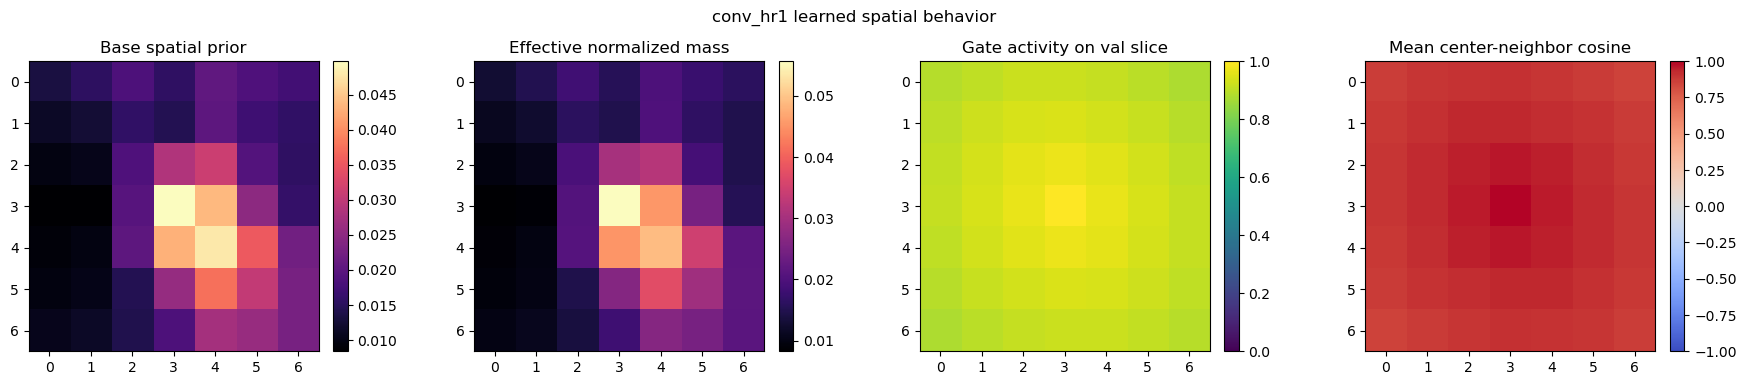

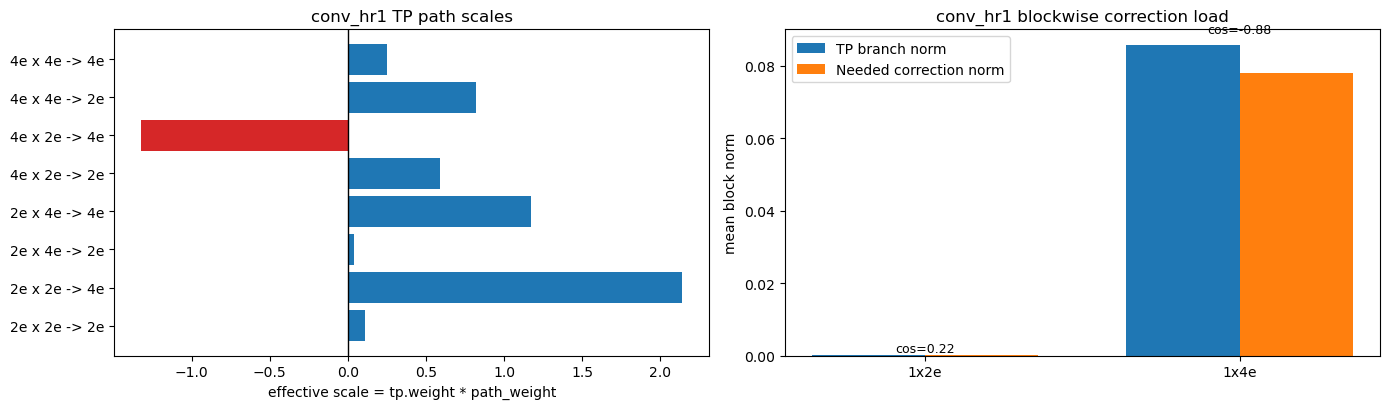

conv_hr2:
  learned base spatial prior center=0.067, ring1=0.273, outer=0.660, entropy=0.928
  on real validation patches effective mass center=0.075, ring1=0.283, outer=0.642
  non-center gate mean=0.923; neighbor/residual cosine=1.000
  feature MSE before=4.110947e-03, after=8.192941e-04, gain=3.291653e-03
  TP vs needed correction cosine=0.945; TP/needed norm ratio=0.918
  dominant output block=1x4e with tp_norm=2.171e-01, needed_norm=2.365e-01, block cosine=0.945
  top TP paths by absolute effective scale:
    4e x 4e -> 4e: eff=4.9278, raw_w=3.2852, path_weight=1.5000
    4e x 4e -> 2e: eff=1.5170, raw_w=1.3568, path_weight=1.1180
    2e x 4e -> 4e: eff=1.3549, raw_w=0.9033, path_weight=1.5000
    2e x 4e -> 2e: eff=0.6619, raw_w=0.5921, path_weight=1.1180


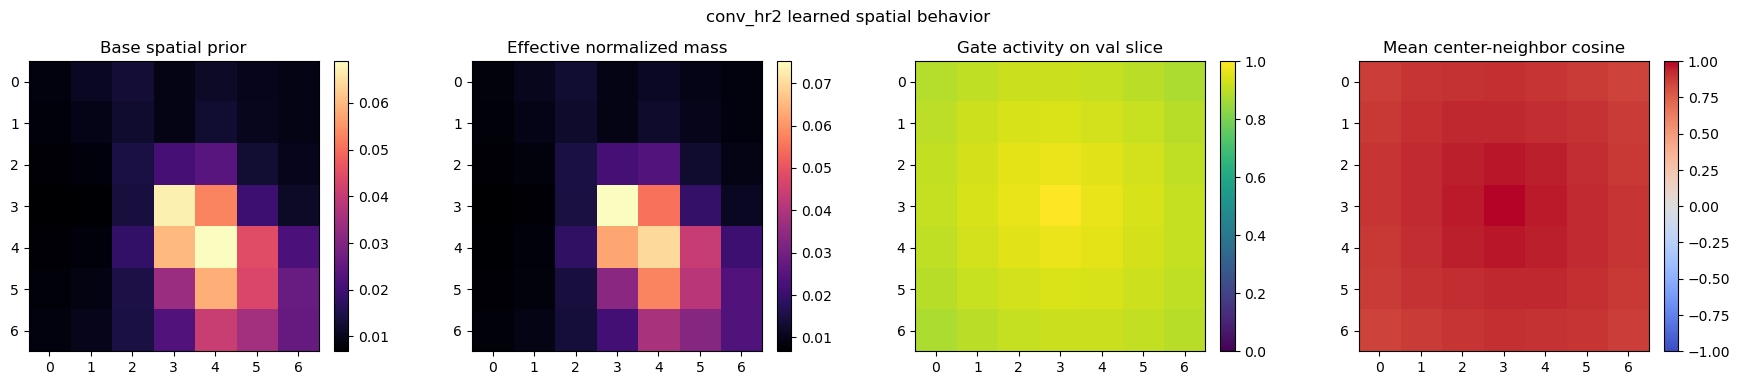

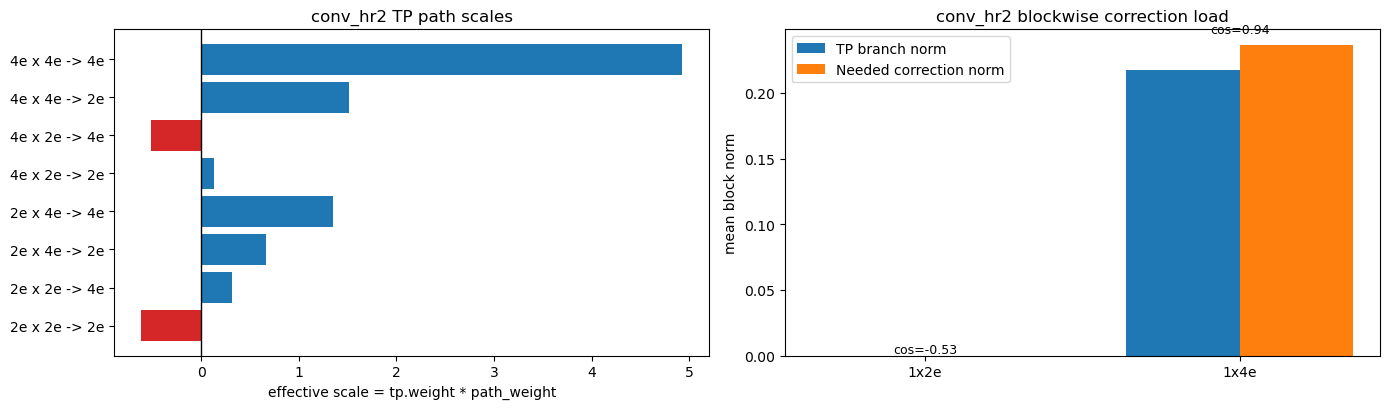

In [ ]:
best_learning = analyze_hr_conv_learning(model, CHECKPOINT_DIR / 'best_model.pt', val_batches)
for conv_name in ['conv_hr1', 'conv_hr2']:
    report = best_learning.get(conv_name)
    if report is not None:
        display_conv_learning_report(report)


### Checkpoint Sweep of the Learned HR-Conv Parameters

The next cell tracks the *parameters themselves* across the saved checkpoints, not just downstream feature error.
It shows:
- the eight TP path scales in each HR conv,
- the learned base center mass,
- and the learned base spatial entropy.


/tmp/ipykernel_1868126/2212568048.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


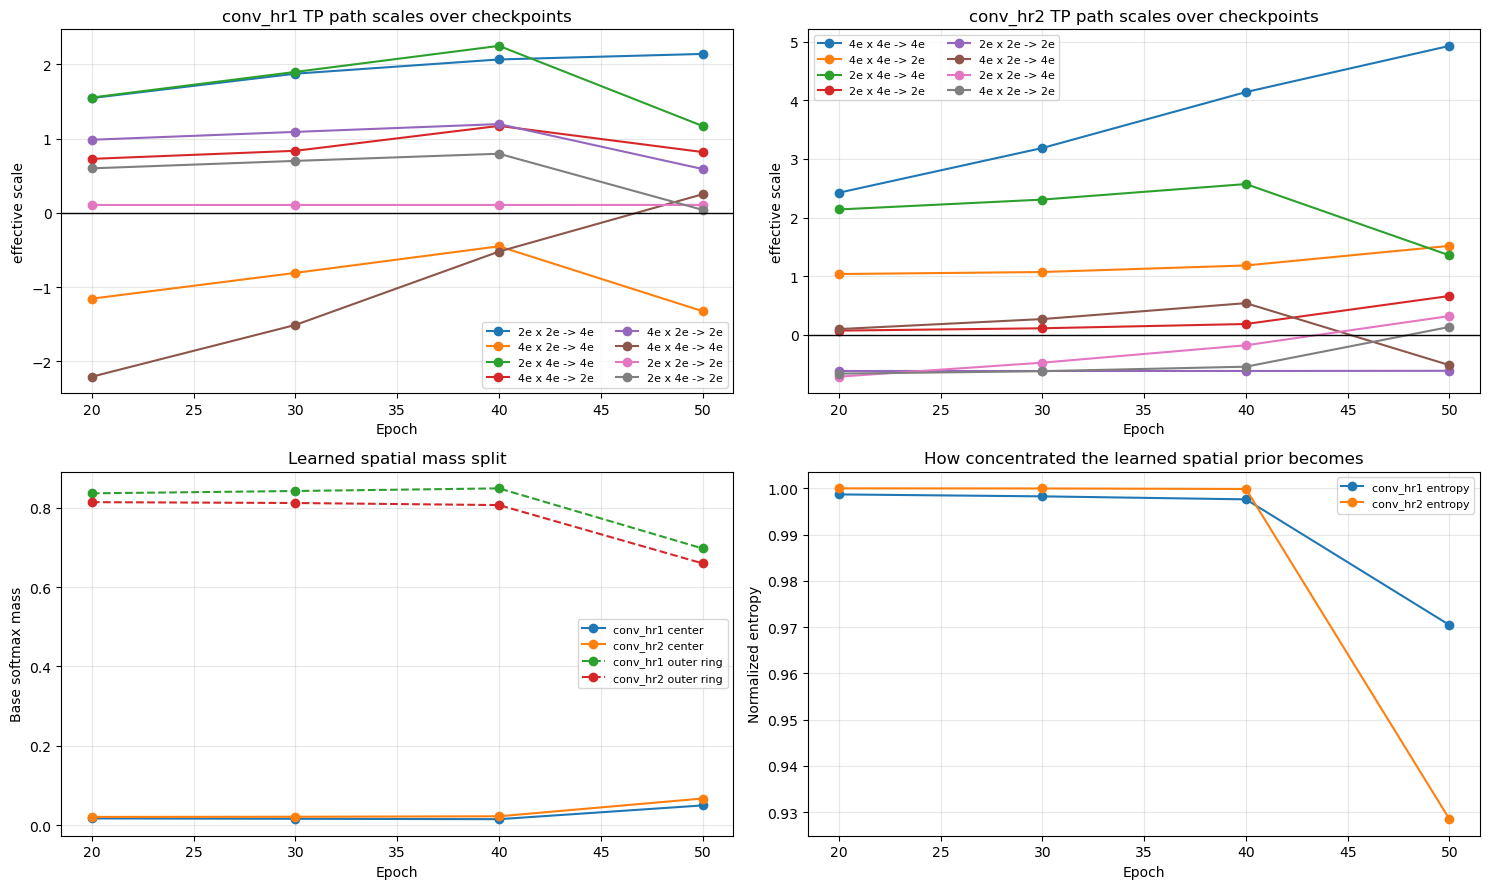

conv_hr1 best-checkpoint top TP paths:
   2e x 2e -> 4e -> 2.1411
   4e x 2e -> 4e -> -1.3240
   2e x 4e -> 4e -> 1.1707
   4e x 4e -> 2e -> 0.8195
conv_hr2 best-checkpoint top TP paths:
   4e x 4e -> 4e -> 4.9278
   4e x 4e -> 2e -> 1.5170
   2e x 4e -> 4e -> 1.3549
   2e x 4e -> 2e -> 0.6619


In [ ]:
def resolve_ckpt_local(label: str) -> Path:
    if label == 'best':
        return CHECKPOINT_DIR / 'best_model.pt'
    return CHECKPOINT_DIR / f'epoch_{int(label):04d}.pt'


def collect_conv_weight_sweep(model, checkpoint_labels):
    rows = []
    for label in checkpoint_labels:
        _ = load_checkpoint_into_model(model, resolve_ckpt_local(label))
        row = {'epoch': label}
        for conv_name in ['conv_hr1', 'conv_hr2']:
            conv = getattr(model, conv_name, None)
            if conv is None:
                continue
            spatial = spatial_kernel_summary(conv)
            row[f'{conv_name}::center_mass'] = spatial['center_mass']
            row[f'{conv_name}::ring1_mass'] = spatial['ring1_mass']
            row[f'{conv_name}::ring2plus_mass'] = spatial['ring2plus_mass']
            row[f'{conv_name}::entropy_0to1'] = spatial['entropy_0to1']
            for path_row in tp_path_rows(conv):
                row[f"{conv_name}::{path_row['path']}"] = path_row['effective_scale']
        rows.append(row)
    return rows


weight_sweep = collect_conv_weight_sweep(model, CHECKPOINT_LABELS)
best_anchor_epoch = int(CHECKPOINT_LABELS[-2]) if len(CHECKPOINT_LABELS) >= 2 else SAVE_EVERY
epoch_x_local = [
    int(row['epoch']) if row['epoch'] != 'best' else best_anchor_epoch + SAVE_EVERY
    for row in weight_sweep
]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for plot_idx, conv_name in enumerate(['conv_hr1', 'conv_hr2']):
    ax = axes[0, plot_idx]
    key_prefix = f'{conv_name}::'
    final_row = weight_sweep[-1]
    path_keys = [k for k in final_row.keys() if k.startswith(key_prefix + '1x')]
    path_keys = sorted(path_keys, key=lambda k: abs(final_row[k]), reverse=True)
    for key in path_keys:
        path_label = pretty_path_label(key.split('::', 1)[1])
        ax.plot(epoch_x_local, [row.get(key, 0.0) for row in weight_sweep], marker='o', label=path_label)
    ax.axhline(0.0, color='black', linewidth=1.0)
    ax.set_title(f'{conv_name} TP path scales over checkpoints')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('effective scale')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

axes[1, 0].plot(epoch_x_local, [row.get('conv_hr1::center_mass', 0.0) for row in weight_sweep], marker='o', label='conv_hr1 center')
axes[1, 0].plot(epoch_x_local, [row.get('conv_hr2::center_mass', 0.0) for row in weight_sweep], marker='o', label='conv_hr2 center')
axes[1, 0].plot(epoch_x_local, [row.get('conv_hr1::ring2plus_mass', 0.0) for row in weight_sweep], marker='o', linestyle='--', label='conv_hr1 outer ring')
axes[1, 0].plot(epoch_x_local, [row.get('conv_hr2::ring2plus_mass', 0.0) for row in weight_sweep], marker='o', linestyle='--', label='conv_hr2 outer ring')
axes[1, 0].set_title('Learned spatial mass split')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Base softmax mass')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(epoch_x_local, [row.get('conv_hr1::entropy_0to1', 0.0) for row in weight_sweep], marker='o', label='conv_hr1 entropy')
axes[1, 1].plot(epoch_x_local, [row.get('conv_hr2::entropy_0to1', 0.0) for row in weight_sweep], marker='o', label='conv_hr2 entropy')
axes[1, 1].set_title('How concentrated the learned spatial prior becomes')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Normalized entropy')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

for conv_name in ['conv_hr1', 'conv_hr2']:
    final_row = weight_sweep[-1]
    key_prefix = f'{conv_name}::'
    top_keys = [k for k in final_row.keys() if k.startswith(key_prefix + '1x')]
    top_keys = sorted(top_keys, key=lambda k: abs(final_row[k]), reverse=True)[:4]
    print(conv_name, 'best-checkpoint top TP paths:')
    for key in top_keys:
        print('  ', pretty_path_label(key.split('::', 1)[1]), f"-> {final_row[key]:.4f}")


## Practical Takeaways

For this HR conv design:
- **Residual on** usually helps learning rather than blocking it.
- **Context pooling** is real, but if the pooled context stays nearly colinear with the center, the TP branch may not become a strong smoother.
- A bend in the loss curve can mark the point where the network starts using the HR conv stack meaningfully, not necessarily the point where it starts smoothing.

If the actual goal is “smoothing first, refinement second,” the cleaner design would be:
- explicit `center/neigh` blend
- then TP refinement on top
- optionally plus a same-grain smoothness loss


## Reference: Saved Training Loss Curves

This is the saved loss-curve figure from the experiment itself:
- `experiments/IN718/iso_embedding_ocrp_01_4x4/visualizations/loss_curves.png`

It is useful to keep this visible while reading the checkpoint sweep above, because the bend near epoch 30 is what motivated the decomposition analysis in this notebook.


/data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_4x4_ocrp_01/visualizations/loss_curves.png


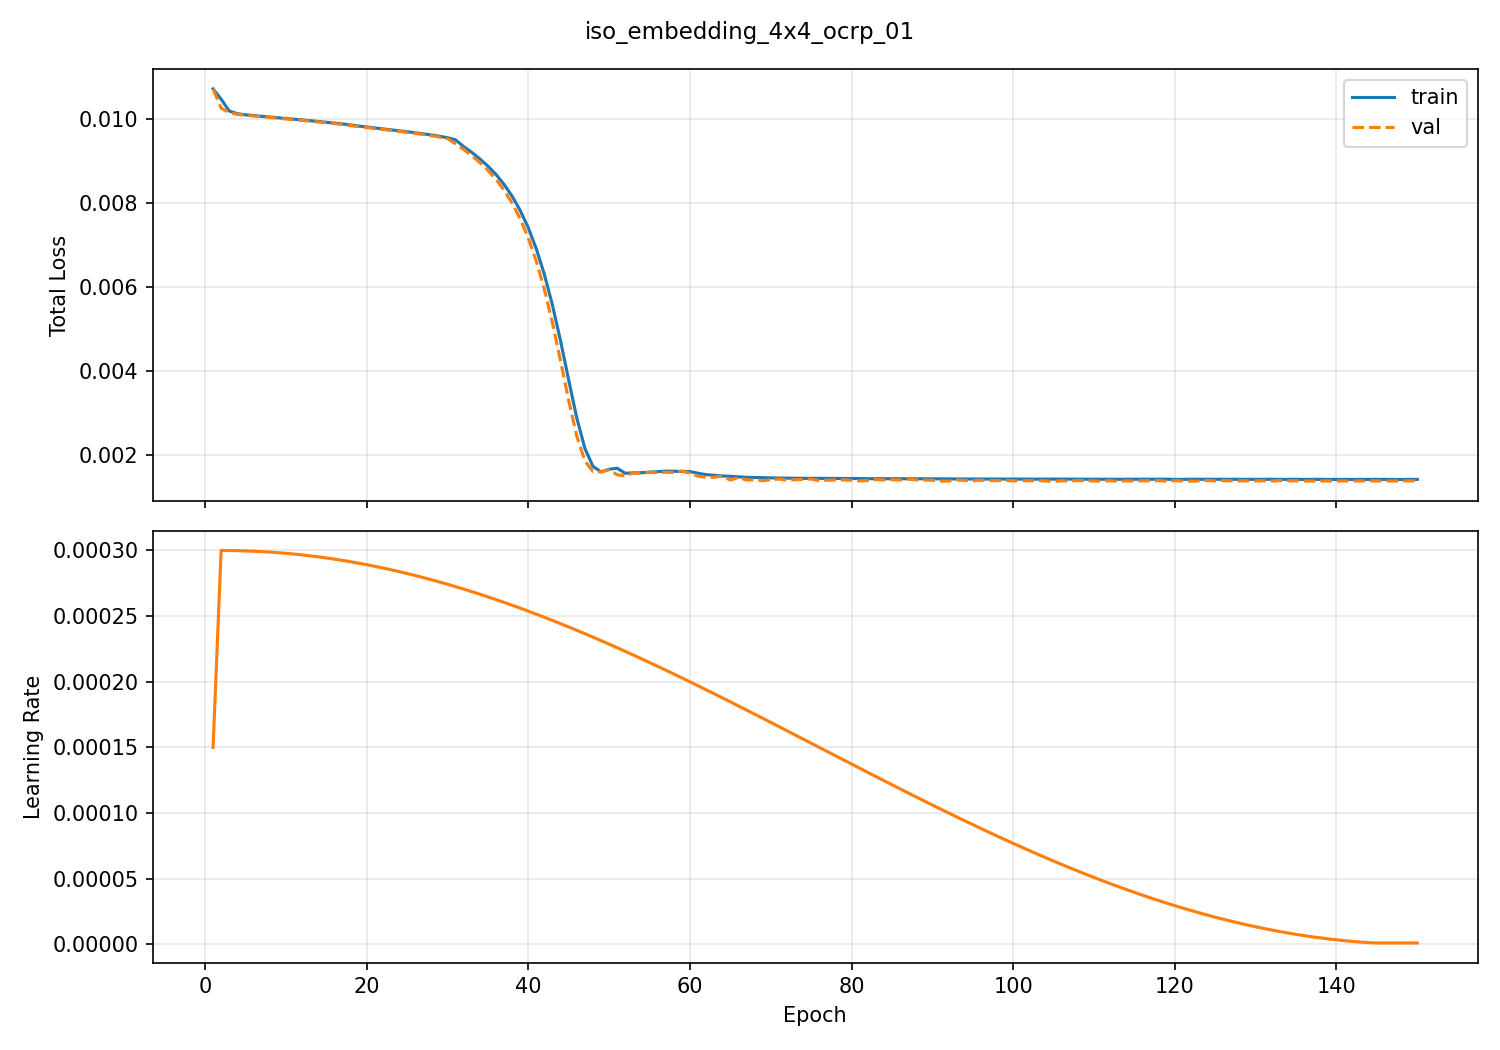

In [ ]:
from IPython.display import Image, display

loss_curve_path = REPO_ROOT / 'experiments' / 'IN718' / 'iso_embedding_4x4_ocrp_01' / 'visualizations' / 'loss_curves.png'
print(loss_curve_path)
display(Image(filename=str(loss_curve_path)))


## Full-Epoch HR-Conv Learning Sweep (All Relevant Checkpoints)

The earlier sweep focuses on the epoch-30 bend. This section extends the same decomposition to **all saved epochs** plus `best`, then summarizes:

- per-conv feature gain/loss (`mse_gain`),
- TP alignment with the needed correction (`tp_needed_cos`),
- TP strength vs needed correction (`tp_over_needed`),
- effective center/ring mass under the runtime gate,
- and top-path identity changes across training.


In [ ]:
ALL_RELEVANT_LABELS = list(available_epoch_labels) + ['best']


def resolve_ckpt_any(label: str) -> Path:
    if label == 'best':
        return CHECKPOINT_DIR / 'best_model.pt'
    return CHECKPOINT_DIR / f"epoch_{int(label):04d}.pt"


def epoch_to_x(label: str) -> int:
    if label == 'best':
        return int(available_epoch_labels[-1]) + SAVE_EVERY
    return int(label)


def collect_full_learning_sweep(model, checkpoint_labels, val_batches):
    rows = []
    reports_by_epoch = {}
    for label in checkpoint_labels:
        reports = analyze_hr_conv_learning(model, resolve_ckpt_any(label), val_batches)
        reports_by_epoch[label] = reports
        for conv_name, report in reports.items():
            top_path = pretty_path_label(report['top_paths'][0]['path']) if report['top_paths'] else 'n/a'
            top_scale = report['top_paths'][0]['effective_scale'] if report['top_paths'] else 0.0
            rows.append(
                {
                    'epoch': label,
                    'epoch_x': epoch_to_x(label),
                    'conv': conv_name,
                    'mse_before': report['mse_before'],
                    'mse_after': report['mse_after'],
                    'mse_gain': report['mse_gain'],
                    'tp_needed_cos': report['tp_needed_cos'],
                    'tp_over_needed': report['tp_over_needed'],
                    'neigh_resid_cos': report['neigh_resid_cos'],
                    'gate_noncenter_mean': report['gate_noncenter_mean'],
                    'effective_center_mass': report['effective_center_mass'],
                    'effective_ring1_mass': report['effective_ring1_mass'],
                    'effective_ring2plus_mass': report['effective_ring2plus_mass'],
                    'top_path': top_path,
                    'top_path_scale': top_scale,
                }
            )
    rows.sort(key=lambda r: (r['epoch_x'], r['conv']))
    return rows, reports_by_epoch


/tmp/ipykernel_1868126/2212568048.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


Full learning sweep labels: ['0010', '0020', '0030', '0040', '0050', '0060', '0070', '0080', '0090', '0100', '0110', '0120', '0130', '0140', '0150', 'best']
Total conv-report rows: 32

conv_hr1
epoch   mse_before   mse_after    mse_gain    tp_needed_cos  tp_over_needed  center  ring2+  top_path
0010 6.918e-03 8.435e-03 -1.517e-03 -0.925 0.115 0.021 0.816 4e x 4e -> 4e
0020 6.601e-03 7.911e-03 -1.310e-03 -0.936 0.104 0.020 0.825 4e x 4e -> 4e
0030 6.289e-03 7.311e-03 -1.023e-03 -0.937 0.086 0.019 0.832 2e x 4e -> 4e
0040 2.217e-03 3.391e-03 -1.174e-03 -0.939 0.311 0.017 0.839 2e x 4e -> 4e
0050 1.385e-03 2.385e-03 -1.000e-03 -0.963 0.866 0.017 0.842 2e x 4e -> 4e
0060 1.455e-03 2.681e-03 -1.226e-03 -0.854 0.883 0.022 0.815 2e x 2e -> 4e
0070 1.181e-03 2.518e-03 -1.337e-03 -0.860 1.132 0.031 0.772 2e x 2e -> 4e
0080 1.167e-03 2.516e-03 -1.349e-03 -0.860 1.155 0.039 0.738 2e x 2e -> 4e
0090 1.149e-03 2.485e-03 -1.336e-03 -0.864 1.134 0.047 0.711 2e x 2e -> 4e
0100 1.179e-03 2.532e-03 -1.3

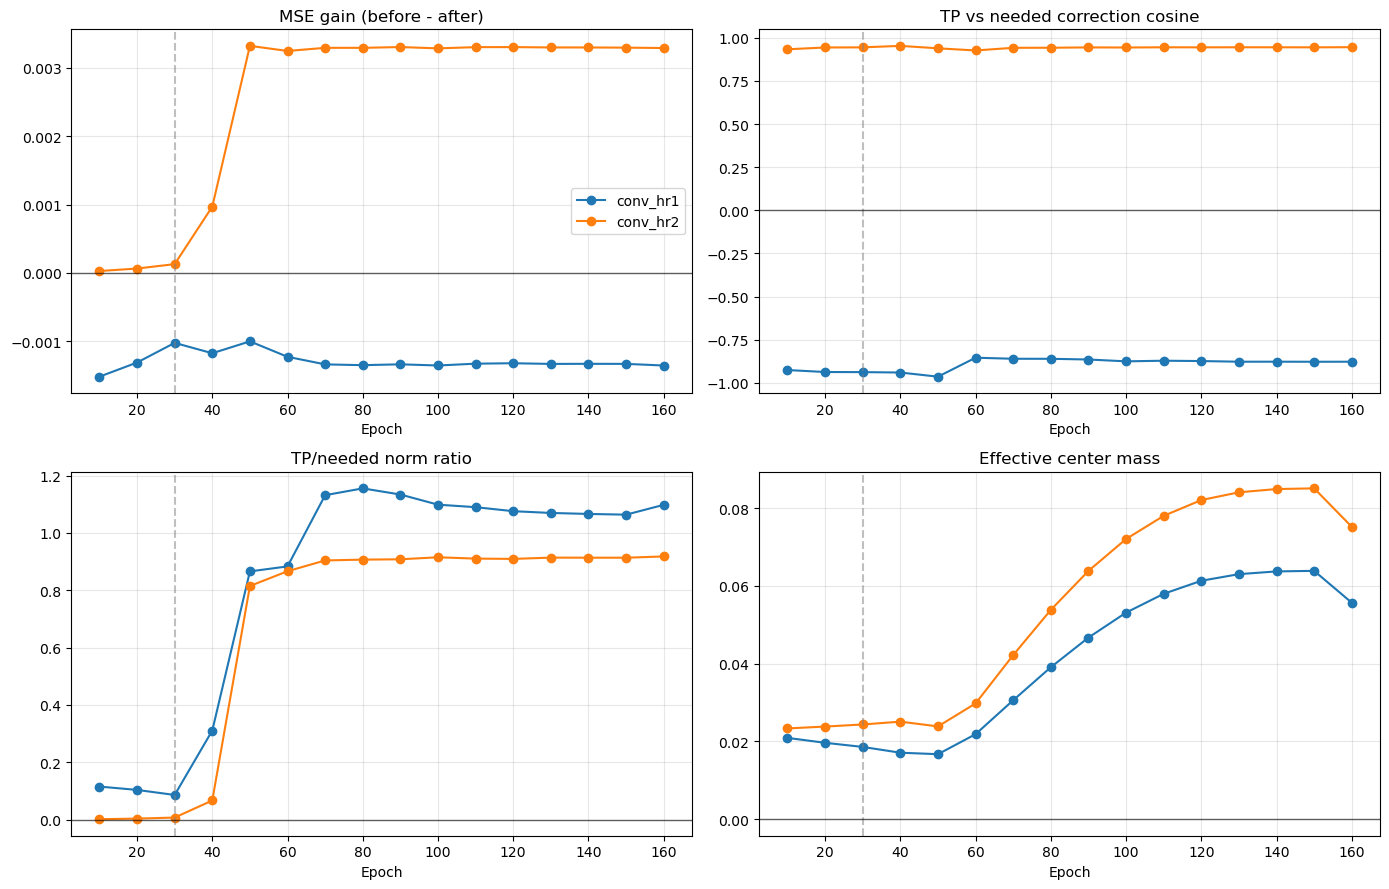

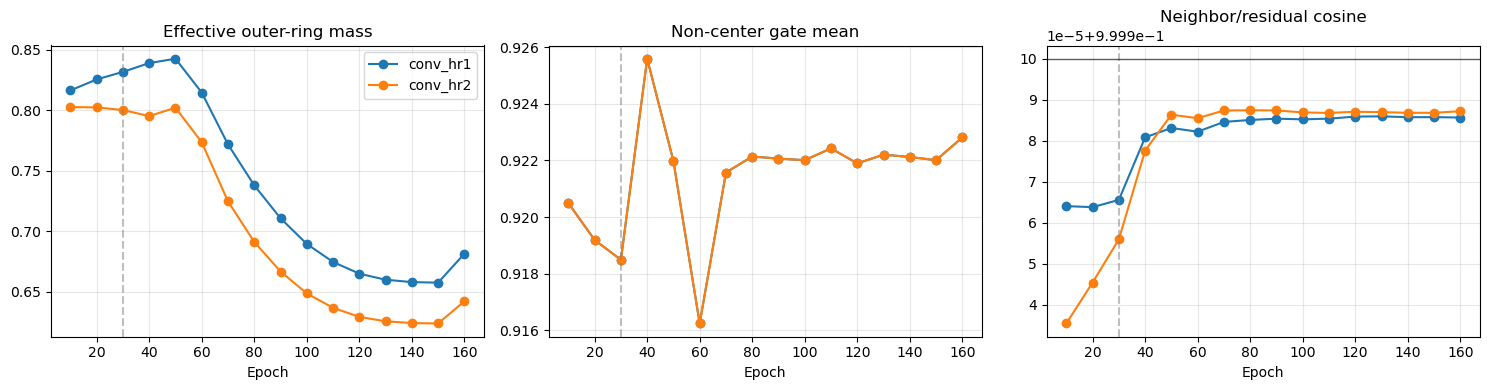


----------------------------------------------------------------------------------------------------
conv_hr1
first non-best epoch with positive mse_gain: None
top-path changes across sweep: 2
top-path sequence: 4e x 4e -> 4e -> 4e x 4e -> 4e -> 2e x 4e -> 4e -> 2e x 4e -> 4e -> 2e x 4e -> 4e -> 2e x 2e -> 4e -> 2e x 2e -> 4e -> 2e x 2e -> 4e -> 2e x 2e -> 4e -> 2e x 2e -> 4e -> 2e x 2e -> 4e -> 2e x 2e -> 4e -> 2e x 2e -> 4e -> 2e x 2e -> 4e -> 2e x 2e -> 4e -> 2e x 2e -> 4e

----------------------------------------------------------------------------------------------------
conv_hr2
first non-best epoch with positive mse_gain: 0010
top-path changes across sweep: 1
top-path sequence: 2e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e -> 4e x 4e -> 4e


In [ ]:
full_learning_rows, full_learning_reports = collect_full_learning_sweep(model, ALL_RELEVANT_LABELS, val_batches)

print('Full learning sweep labels:', ALL_RELEVANT_LABELS)
print('Total conv-report rows:', len(full_learning_rows))

for conv_name in ['conv_hr1', 'conv_hr2']:
    rows = [r for r in full_learning_rows if r['conv'] == conv_name]
    rows = sorted(rows, key=lambda r: r['epoch_x'])
    print('\n' + '=' * 100)
    print(conv_name)
    print('epoch   mse_before   mse_after    mse_gain    tp_needed_cos  tp_over_needed  center  ring2+  top_path')
    for r in rows:
        print(
            f"{str(r['epoch']).rjust(4)} "
            f"{r['mse_before']:.3e} {r['mse_after']:.3e} {r['mse_gain']:+.3e} "
            f"{r['tp_needed_cos']:+.3f} {r['tp_over_needed']:.3f} "
            f"{r['effective_center_mass']:.3f} {r['effective_ring2plus_mass']:.3f} {r['top_path']}"
        )

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metric_specs = [
    ('mse_gain', 'MSE gain (before - after)'),
    ('tp_needed_cos', 'TP vs needed correction cosine'),
    ('tp_over_needed', 'TP/needed norm ratio'),
    ('effective_center_mass', 'Effective center mass'),
]
for ax, (metric, title) in zip(axes.flat, metric_specs):
    for conv_name in ['conv_hr1', 'conv_hr2']:
        rows = sorted([r for r in full_learning_rows if r['conv'] == conv_name], key=lambda r: r['epoch_x'])
        ax.plot([r['epoch_x'] for r in rows], [r[metric] for r in rows], marker='o', label=conv_name)
    ax.axvline(30, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(0.0, color='black', linewidth=1.0, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
axes[0, 0].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metric_specs_2 = [
    ('effective_ring2plus_mass', 'Effective outer-ring mass'),
    ('gate_noncenter_mean', 'Non-center gate mean'),
    ('neigh_resid_cos', 'Neighbor/residual cosine'),
]
for ax, (metric, title) in zip(axes, metric_specs_2):
    for conv_name in ['conv_hr1', 'conv_hr2']:
        rows = sorted([r for r in full_learning_rows if r['conv'] == conv_name], key=lambda r: r['epoch_x'])
        ax.plot([r['epoch_x'] for r in rows], [r[metric] for r in rows], marker='o', label=conv_name)
    ax.axvline(30, color='gray', linestyle='--', alpha=0.5)
    if metric == 'neigh_resid_cos':
        ax.axhline(1.0, color='black', linewidth=1.0, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()

for conv_name in ['conv_hr1', 'conv_hr2']:
    rows = sorted([r for r in full_learning_rows if r['conv'] == conv_name], key=lambda r: r['epoch_x'])
    positive = [r for r in rows if (r['epoch'] != 'best') and (r['mse_gain'] > 0)]
    first_positive = positive[0]['epoch'] if positive else None
    top_seq = [r['top_path'] for r in rows]
    path_changes = sum(int(a != b) for a, b in zip(top_seq[:-1], top_seq[1:]))
    print('\n' + '-' * 100)
    print(conv_name)
    print('first non-best epoch with positive mse_gain:', first_positive)
    print('top-path changes across sweep:', path_changes)
    print('top-path sequence:', ' -> '.join(top_seq))

## Is the HR Conv Basically Identity, or Is It Learning Something Structured?

The next cells make the identity question explicit. For each HR conv, they ask:
- is the **final layer output** close to its input feature map,
- is the **TP branch** mostly reconstructing the correction required for exact identity,
- or is it better aligned with the correction needed to reach the HR target feature,
- and does the layer act more strongly on locally heterogeneous sites than on easy interior sites?

That last point matters: a near-identity operator with stronger corrections near hard structure is still interesting, while a globally uniform near-identity map is much less so.


In [ ]:
def active_hr_conv_specs(model):
    specs = []
    if getattr(model, 'use_hr_conv1', False) and getattr(model, 'conv_hr1', None) is not None:
        specs.append(('conv_hr1', model.conv_hr1, 'feat_hr_raw_ocrp', 'feat_hr_post_hr_conv1'))
    if getattr(model, 'use_hr_conv2', False) and getattr(model, 'conv_hr2', None) is not None:
        specs.append(('conv_hr2', model.conv_hr2, 'feat_hr_post_hr_conv1', 'feat_hr_post_hr_conv2'))
    return specs


def _safe_quantile(x: torch.Tensor, q: float) -> float:
    if x.numel() == 0:
        return 0.0
    return float(torch.quantile(x, q).item())


def mean_projection_scale(a: torch.Tensor, b: torch.Tensor) -> float:
    aa = a.reshape(-1, a.shape[-1])
    bb = b.reshape(-1, b.shape[-1])
    denom = bb.pow(2).sum(dim=-1).clamp_min(1e-8)
    scale = (aa * bb).sum(dim=-1) / denom
    return float(torch.nan_to_num(scale, nan=0.0).mean().item())


def heuristic_identity_read(report):
    if report['target_gain'] <= 0 and report['out_input_cos'] > 0.99 and abs(report['out_input_scale'] - 1.0) > 0.20:
        return 'The layer is mostly preserving direction while rescaling amplitude, and on this slice that rescaling is not helping target error.'
    if report['target_gain'] <= 0:
        return 'On this validation slice the layer is not reducing target feature error, so any non-identity behavior here is not obviously useful.'
    if report['tp_target_cos'] > report['tp_identity_cos'] + 0.10 and report['heter_delta_ratio'] > 1.15:
        return 'The layer is not just rebuilding identity: its TP branch is better aligned with the target-needed correction, and its updates grow on locally heterogeneous sites.'
    if report['rel_change_vs_input'] < 0.10 and report['out_input_cos'] > 0.97:
        return 'Globally the layer stays close to identity, but it still makes useful low-amplitude corrections rather than being a pure no-op.'
    if report['tp_identity_cos'] > report['tp_target_cos'] + 0.10:
        return 'The learned TP branch looks more identity-restoring than target-correcting, so this layer is behaving closer to a conservative skip-preserving transform.'
    return 'The layer is intermediate: not a no-op, not wildly non-identity, and its useful behavior needs to be judged together with the target-error gain.'


def analyze_hr_conv_identity_behavior(model, ckpt_path: Path, val_batches, heter_bins: int = 5):
    _ = load_checkpoint_into_model(model, ckpt_path)
    model.eval()
    reports = {}
    conv_specs = active_hr_conv_specs(model)
    bin_edges = torch.linspace(0.0, 1.0, heter_bins + 1)

    for conv_name, conv, _, _ in conv_specs:
        reports[conv_name] = {
            'conv_name': conv_name,
            'tokens': 0,
            'identity_mse': 0.0,
            'target_mse_before': 0.0,
            'target_mse_after': 0.0,
            'out_input_cos': 0.0,
            'out_input_scale': 0.0,
            'delta_norm': 0.0,
            'input_norm': 0.0,
            'output_norm': 0.0,
            'tp_input_scale': 0.0,
            'tp_norm': 0.0,
            'identity_needed_norm': 0.0,
            'target_needed_norm': 0.0,
            'tp_identity_cos': 0.0,
            'tp_target_cos': 0.0,
            'delta_target_cos': 0.0,
            'heter_low_delta_sum': 0.0,
            'heter_low_count': 0,
            'heter_high_delta_sum': 0.0,
            'heter_high_count': 0,
            '_heter_bin_sums': torch.zeros(heter_bins, dtype=torch.float64),
            '_heter_bin_counts': torch.zeros(heter_bins, dtype=torch.long),
            '_heter_bin_edges': bin_edges.clone(),
        }

    with torch.no_grad():
        for batch in val_batches:
            lr, hr, _ = _unpack_batch(batch)
            lr_flat, lr_shape = _flatten_quat_chw_batch(lr)
            hr_flat, _ = _flatten_quat_chw_batch(hr)
            feat_lr = model.encode(lr_flat)
            _, hr_pred_shape, aux = model._forward_sr_features(
                lr_quats=lr_flat,
                feat_lr=feat_lr,
                lr_shape=lr_shape,
                return_aux=True,
            )
            feat_hr_tgt = model.encode(hr_flat)
            h_hr, w_hr = hr_pred_shape

            for conv_name, conv, input_key, output_key in conv_specs:
                report = reports[conv_name]
                inp = aux[input_key]
                out = aux.get(output_key, aux['feat_hr_post_hr_conv'])
                dec = decompose_conv_rich(conv, inp, hr_pred_shape)

                identity_needed = inp - dec['resid']
                target_needed = feat_hr_tgt - dec['resid']
                delta = out - inp
                target_delta = feat_hr_tgt - inp

                bsz, n, _ = inp.shape
                t = bsz * n
                report['tokens'] += t
                report['identity_mse'] += float(F.mse_loss(out, inp).item()) * t
                report['target_mse_before'] += float(F.mse_loss(inp, feat_hr_tgt).item()) * t
                report['target_mse_after'] += float(F.mse_loss(out, feat_hr_tgt).item()) * t
                report['out_input_cos'] += safe_mean_cos(out, inp) * t
                report['out_input_scale'] += mean_projection_scale(out, inp) * t
                report['delta_norm'] += mean_norm(delta) * t
                report['input_norm'] += mean_norm(inp) * t
                report['output_norm'] += mean_norm(out) * t
                report['tp_input_scale'] += mean_projection_scale(dec['tp'], inp) * t
                report['tp_norm'] += mean_norm(dec['tp']) * t
                report['identity_needed_norm'] += mean_norm(identity_needed) * t
                report['target_needed_norm'] += mean_norm(target_needed) * t
                report['tp_identity_cos'] += safe_mean_cos(dec['tp'], identity_needed) * t
                report['tp_target_cos'] += safe_mean_cos(dec['tp'], target_needed) * t
                report['delta_target_cos'] += safe_mean_cos(delta, target_delta) * t

                noncenter_mask = (~conv.center_mask).reshape(conv.kernel_size, conv.kernel_size)
                heter = 1.0 - dec['cosine'][..., noncenter_mask].mean(dim=-1)
                delta_map = delta.view(bsz, h_hr, w_hr, -1).norm(dim=-1)
                flat_heter = heter.reshape(-1).cpu()
                flat_delta = delta_map.reshape(-1).cpu()

                lo_thr = _safe_quantile(flat_heter, 0.25)
                hi_thr = _safe_quantile(flat_heter, 0.75)
                low_mask = flat_heter <= lo_thr
                high_mask = flat_heter >= hi_thr
                if low_mask.any():
                    report['heter_low_delta_sum'] += float(flat_delta[low_mask].sum().item())
                    report['heter_low_count'] += int(low_mask.sum().item())
                if high_mask.any():
                    report['heter_high_delta_sum'] += float(flat_delta[high_mask].sum().item())
                    report['heter_high_count'] += int(high_mask.sum().item())

                clipped = flat_heter.clamp(0.0, 1.0 - 1e-6)
                bucket = torch.bucketize(clipped, report['_heter_bin_edges'][1:-1], right=False)
                for bin_idx in range(report['_heter_bin_sums'].numel()):
                    mask = bucket == bin_idx
                    if mask.any():
                        report['_heter_bin_sums'][bin_idx] += flat_delta[mask].sum().double()
                        report['_heter_bin_counts'][bin_idx] += int(mask.sum().item())

    for report in reports.values():
        tokens = max(int(report['tokens']), 1)
        for key in [
            'identity_mse',
            'target_mse_before',
            'target_mse_after',
            'out_input_cos',
            'out_input_scale',
            'delta_norm',
            'input_norm',
            'output_norm',
            'tp_input_scale',
            'tp_norm',
            'identity_needed_norm',
            'target_needed_norm',
            'tp_identity_cos',
            'tp_target_cos',
            'delta_target_cos',
        ]:
            report[key] /= tokens
        report['rel_change_vs_input'] = report['delta_norm'] / max(report['input_norm'], 1e-12)
        report['out_over_input_norm'] = report['output_norm'] / max(report['input_norm'], 1e-12)
        report['tp_over_identity'] = report['tp_norm'] / max(report['identity_needed_norm'], 1e-12)
        report['tp_over_target'] = report['tp_norm'] / max(report['target_needed_norm'], 1e-12)
        report['target_gain'] = report['target_mse_before'] - report['target_mse_after']
        report['heter_low_delta_mean'] = report['heter_low_delta_sum'] / max(report['heter_low_count'], 1)
        report['heter_high_delta_mean'] = report['heter_high_delta_sum'] / max(report['heter_high_count'], 1)
        report['heter_delta_ratio'] = report['heter_high_delta_mean'] / max(report['heter_low_delta_mean'], 1e-12)
        edges = report.pop('_heter_bin_edges')
        sums = report.pop('_heter_bin_sums')
        counts = report.pop('_heter_bin_counts')
        report['heter_bin_centers'] = ((edges[:-1] + edges[1:]) * 0.5).tolist()
        report['heter_bin_delta_mean'] = [
            float((sums[i] / max(int(counts[i].item()), 1)).item())
            for i in range(len(sums))
        ]
        report['heuristic_read'] = heuristic_identity_read(report)
    return reports


def display_hr_conv_identity_report(report):
    print('=' * 100)
    print(report['conv_name'])
    print('heuristic read:', report['heuristic_read'])
    print(
        f"target MSE before={report['target_mse_before']:.6e}, after={report['target_mse_after']:.6e}, "
        f"gain={report['target_gain']:+.6e}"
    )
    print(
        f"identity MSE to input={report['identity_mse']:.6e}; out/input cosine={report['out_input_cos']:.4f}; "
        f"projection scale={report['out_input_scale']:.4f}; norm ratio={report['out_over_input_norm']:.4f}; "
        f"relative change norm={report['rel_change_vs_input']:.4f}"
    )
    print(
        f"TP vs identity-needed cosine={report['tp_identity_cos']:+.4f}; TP/identity-needed norm={report['tp_over_identity']:.4f}; "
        f"TP/input projection scale={report['tp_input_scale']:.4f}"
    )
    print(
        f"TP vs target-needed cosine={report['tp_target_cos']:+.4f}; TP/target-needed norm={report['tp_over_target']:.4f}; "
        f"delta/target-delta cosine={report['delta_target_cos']:+.4f}"
    )
    print(
        f"delta norm on easy interior-ish sites={report['heter_low_delta_mean']:.4e}; "
        f"on hard heterogeneous sites={report['heter_high_delta_mean']:.4e}; ratio={report['heter_delta_ratio']:.3f}"
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].bar(
        ['target before', 'target after', 'input'],
        [report['target_mse_before'], report['target_mse_after'], report['identity_mse']],
        color=['tab:gray', 'tab:green', 'tab:blue'],
    )
    axes[0].set_title(f"{report['conv_name']}: target gain vs identity closeness")
    axes[0].set_ylabel('feature MSE')
    axes[0].grid(True, axis='y', alpha=0.3)

    axes[1].bar(
        ['out~input', 'TP~identity', 'TP~target', 'delta~target'],
        [
            report['out_input_cos'],
            report['tp_identity_cos'],
            report['tp_target_cos'],
            report['delta_target_cos'],
        ],
        color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'],
    )
    axes[1].axhline(1.0, color='black', linewidth=1.0, alpha=0.5)
    axes[1].axhline(0.0, color='black', linewidth=1.0, alpha=0.5)
    axes[1].set_title('Which direction does the layer point?')
    axes[1].set_ylabel('cosine similarity')
    axes[1].grid(True, axis='y', alpha=0.3)

    axes[2].plot(report['heter_bin_centers'], report['heter_bin_delta_mean'], marker='o', color='tab:purple')
    axes[2].set_title('Update strength vs local heterogeneity')
    axes[2].set_xlabel('heterogeneity bin center')
    axes[2].set_ylabel('mean ||out - input||')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [ ]:
best_identity = analyze_hr_conv_identity_behavior(model, CHECKPOINT_DIR / 'best_model.pt', val_batches)
for conv_name, *_ in active_hr_conv_specs(model):
    display_hr_conv_identity_report(best_identity[conv_name])


In [ ]:
def collect_hr_conv_identity_sweep(model, checkpoint_labels, val_batches):
    rows = []
    for label in checkpoint_labels:
        ckpt_path = resolve_ckpt_local(label)
        reports = analyze_hr_conv_identity_behavior(model, ckpt_path, val_batches)
        epoch_x = int(label) if label != 'best' else (int(checkpoint_labels[-2]) + SAVE_EVERY if len(checkpoint_labels) >= 2 else SAVE_EVERY)
        for conv_name, report in reports.items():
            rows.append({
                'epoch': label,
                'epoch_x': epoch_x,
                'conv': conv_name,
                'target_gain': report['target_gain'],
                'identity_mse': report['identity_mse'],
                'out_input_cos': report['out_input_cos'],
                'rel_change_vs_input': report['rel_change_vs_input'],
                'tp_identity_cos': report['tp_identity_cos'],
                'tp_target_cos': report['tp_target_cos'],
                'heter_delta_ratio': report['heter_delta_ratio'],
            })
    return rows


identity_sweep_rows = collect_hr_conv_identity_sweep(model, ALL_RELEVANT_LABELS, val_batches)
print('Identity sweep labels:', ALL_RELEVANT_LABELS)

for conv_name, *_ in active_hr_conv_specs(model):
    rows = sorted([r for r in identity_sweep_rows if r['conv'] == conv_name], key=lambda r: r['epoch_x'])
    print('\n' + '-' * 100)
    print(conv_name)
    print('epoch   target_gain   rel_change   out~input   tp~identity   tp~target   heter_ratio')
    for r in rows:
        print(
            f"{str(r['epoch']).rjust(4)} "
            f"{r['target_gain']:+.3e} {r['rel_change_vs_input']:.3f} {r['out_input_cos']:.3f} "
            f"{r['tp_identity_cos']:+.3f} {r['tp_target_cos']:+.3f} {r['heter_delta_ratio']:.3f}"
        )

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metric_specs = [
    ('target_gain', 'Target MSE gain'),
    ('rel_change_vs_input', 'Relative change vs input'),
    ('tp_identity_cos', 'TP vs identity-needed cosine'),
    ('heter_delta_ratio', 'Hard/easy update ratio'),
]
for ax, (metric, title) in zip(axes.flat, metric_specs):
    for conv_name, *_ in active_hr_conv_specs(model):
        rows = sorted([r for r in identity_sweep_rows if r['conv'] == conv_name], key=lambda r: r['epoch_x'])
        ax.plot([r['epoch_x'] for r in rows], [r[metric] for r in rows], marker='o', label=conv_name)
    ax.axvline(30, color='gray', linestyle='--', alpha=0.5)
    if metric in {'target_gain', 'tp_identity_cos'}:
        ax.axhline(0.0, color='black', linewidth=1.0, alpha=0.6)
    if metric == 'tp_identity_cos':
        ax.axhline(1.0, color='black', linewidth=1.0, alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
axes[0, 0].legend()
plt.tight_layout()
plt.show()
